# Tech Challenge: Detecção de Pneumonia em Radiografias

**Autor:** Lucas dos Santos Camilo

## Ingestão de Dados e Portabilidade

Para garantir que este projeto seja executado sem falhas em diferentes sistemas operacionais (Windows e Linux/Colab), implementamos uma estratégia de ingestão de dados robusta e multiplataforma:

* KaggleHub: Utilizamos a biblioteca `kagglehub`, a ferramenta mais moderna e simplificada para integração com o ecossistema Kaggle. Ela automatiza o download e a gestão de versões do dataset diretamente via código.

* Pathlib (Cross-Platform): Substituímos caminhos de texto estáticos pela biblioteca `pathlib`. Isso permite que o código entenda automaticamente se deve usar barras para a direita (`/` no Linux/Colab) ou invertidas (`\` no Windows), eliminando erros de diretório.

* Automação e Persistência:

  * O script realiza uma verificação inteligente: se o dataset já existir na pasta local `../../datasets/chest_xray`, ele avança direto para o processamento.

  * Caso contrário, ele faz o download, identifica a pasta de origem e utiliza a biblioteca `shutil` para organizar os arquivos na estrutura correta do projeto.

Essa abordagem economiza tempo de processamento, evita downloads redundantes e garante que qualquer membro da equipe consiga rodar o projeto sem precisar configurar caminhos manuais.

In [1]:
# --- IMPORTA AS FERRAMENTAS ---
from pathlib import Path
import shutil
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# --- INGESTÃO E CONFIGURAÇÃO DO AMBIENTE ---
dataset_path = Path("../../datasets/chest_xray")

# --- VERIFICA LOCAL DO DATASET E FAZ O DOWNLOAD SE FOR PRECISO ---
if not dataset_path.exists():
    print("Dataset não localizado no diretório. Iniciando download via KaggleHub...")

    downloaded_path = Path(
        kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
    )

    print("Download finalizado.")
    print("Path original do KaggleHub:", downloaded_path)

    source_path = downloaded_path / "chest_xray"

    if not source_path.exists():
        source_path = downloaded_path

    print("Copiando dataset para:", dataset_path)

    shutil.copytree(source_path, dataset_path)

    print("Dataset copiado para a pasta correta.")
else:
    print("Dataset previamente carregado. Avançando para o processamento.")

print("Caminho final usado:", dataset_path)

C:\dev\fiap\tech-challenge-fiap\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset não localizado no diretório. Iniciando download via KaggleHub...


100%|██████████| 2.29G/2.29G [01:11<00:00, 34.5MB/s]

Extracting files...


Download finalizado.
Path original do KaggleHub: C:\Users\gusta\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
Copiando dataset para: ..\..\datasets\chest_xray
Dataset copiado para a pasta correta.
Caminho final usado: ..\..\datasets\chest_xray


## Transformação de Dados e Data Augmentation

Antes de treinar o modelo, eu fiz o pré-processamento das imagens para garantir que tudo estivesse no padrão correto.

Padronizei todas as imagens para **224x224 pixels**, que é o tamanho esperado pela rede que estou utilizando. Também apliquei o *rescale*, ajustando os valores dos pixels para uma faixa menor, o que ajuda o modelo a aprender melhor.

Além disso, utilizei **Data Augmentation**, mas somente nos dados de treino. Criei variações nas imagens, como:
- rotação  
- zoom  

A ideia aqui não é aumentar os dados só por aumentar, mas evitar que o modelo decore as imagens. Com isso, ele aprende padrões mais gerais e consegue se sair melhor quando recebe imagens novas, principalmente na detecção de patologias pulmonares.


In [2]:
# --- TRATANDO AS IMAGENS ---
train_path = '../../datasets/chest_xray/train'
test_path = '../../datasets/chest_xray/test'
val_path = '../../datasets/chest_xray/val'
img_size = (224, 224) # Tamanho padrão que a MobileNet exige
batch_size = 32 # Quantas fotos a IA olha por vez antes de aprender um pouco

# Configura o "estudo" do nosso modelo: nesse bloco giramos e distorcemos as fotos pro modelo não decorar as imagens
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Deixa os pixels entre 0 e 1 para facilitar os cálculos
    rotation_range=15,        # Gira a foto aleatoriamente em qualquer ângulo entre -15 e +15 graus
    width_shift_range=0.1,    # Move a imagem horizontalmente por uma proporção de 10% da largura total da imagem
    height_shift_range=0.1,   # Move a imagem verticalmente por uma proporção de 10% da altura total da imagem
    shear_range=0.1,          # Dá uma entortada na imagem
    zoom_range=0.1,           # Dá um zoom aleatório
    horizontal_flip=True,     # Inverte a foto (ajuda o modelo a ver o pulmão de vários jeitos)
    fill_mode='nearest'       # Se sobrar espaço vazio depois de girar, ele preenche com a cor vizinha
)

# Pro teste e validação a gente não mexe na foto, só ajusta a escala de 0 a 1
test_datagen = ImageDataGenerator(rescale=1./255)

# Carrega as fotos direto das pastas (só carrega o que vai usar na hora)
train_generator = train_datagen.flow_from_directory(
    train_path, target_size=img_size, batch_size=batch_size, class_mode='binary')

# shuffle=False mantém a ordem pra gente saber qual resposta é de qual foto
test_generator = test_datagen.flow_from_directory(
    test_path, target_size=img_size, batch_size=batch_size, class_mode='binary', shuffle=False)

val_generator = test_datagen.flow_from_directory(
    val_path, target_size=img_size, batch_size=batch_size, class_mode='binary')

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


## Arquitetura Neural e Transfer Learning

Para a arquitetura, optei por usar a MobileNetV2 como base.

Utilizei a estratégia de **Transfer Learning**, ou seja, aproveitei uma rede já treinada e adaptei para o meu problema.

O que eu fiz na prática:
- Congelei a base convolucional (ela não é treinada novamente)  
- Adicionei camadas densas no final da rede  
- Incluí um **Dropout de 30%** para evitar overfitting  

No final, o modelo foi ajustado para fazer uma **classificação binária**, identificando se o paciente tem pneumonia ou não.


In [3]:
# DEFINIÇÃO DA ARQUITETURA (TRANSFER LEARNING)
# Carregamento do modelo base com pesos do ImageNet e remoção do classificador final (top).
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Congela as camadas convolucionais para agir apenas como extrator de features.

model = models.Sequential([               # Empilha as camadas da nossa rede
    base_model,                           # MobileNet
    layers.GlobalAveragePooling2D(),      # Achata os dados da imagem pra preparar pro resultado
    layers.Dense(128, activation='relu'), # Camada de neurônios pra pensar nos padrões
    layers.Dropout(0.3),                  # Desliga 30% dos neurônios na sorte pro modelo não ficar "preguiçoso"
    layers.Dense(1, activation='sigmoid') # Resultado final: uma chance entre 0 e 1
])

# COMPILAÇÃO E TREINAMENTO
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

history = model.fit(
    train_generator,
    epochs=10,                        # Repete o estudo 10 vezes
    validation_data=val_generator     # No fim de cada rodada, ele simula os dados de validação
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 283ms/step - accuracy: 0.9143 - loss: 0.2092 - recall: 0.9481 - val_accuracy: 0.7500 - val_loss: 0.3861 - val_recall: 1.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 269ms/step - accuracy: 0.9494 - loss: 0.1264 - recall: 0.9662 - val_accuracy: 0.8750 - val_loss: 0.2414 - val_recall: 0.7500
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 270ms/step - accuracy: 0.9526 - loss: 0.1234 - recall: 0.9695 - val_accuracy: 0.8125 - val_loss: 0.2822 - val_recall: 0.8750
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 271ms/step - accuracy: 0.9532 - loss: 0.1124 - recall: 0.9688 - val_accuracy: 0.8125 - val_loss: 0.2959 - val_recall: 1.0000
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 269ms/step - accuracy: 0.9567 - loss: 0.1028 - recall: 0.9719 - val_accuracy: 0.8125 - val_loss: 0.2674 - val_recall: 1.0000
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 270ms/step - accuracy: 0.9653 - loss: 0.0910 - recall: 0.9742 - val_accuracy: 0.8125 - val_loss: 0.3402 - val_r

## Avaliação de Desempenho

Depois do treinamento, foquei em entender como o modelo está se comportando.

Utilizei:
- **Matriz de Confusão**  para visualizar os acertos e os erros  
- **Relatório de Classificação** com métricas como precisão, recall e F1-score  

Em um contexto médico, o mais importante aqui é reduzir **falsos negativos**, ou seja, evitar casos em que o modelo diz que está tudo normal quando na verdade não está.


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step


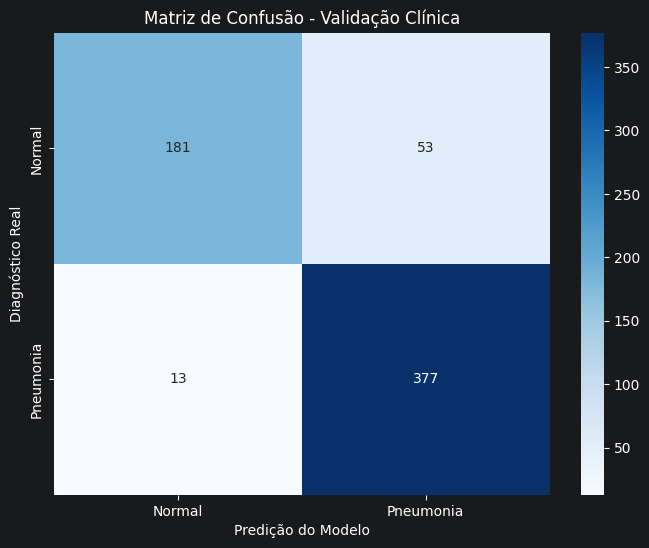

              precision    recall  f1-score   support

      Normal       0.93      0.77      0.85       234
   Pneumonia       0.88      0.97      0.92       390

    accuracy                           0.89       624
   macro avg       0.90      0.87      0.88       624
weighted avg       0.90      0.89      0.89       624



In [4]:
# AVALIAÇÃO
y_pred_prob = model.predict(test_generator) # Pede os palpites do modelo pras fotos de teste
y_pred = (y_pred_prob > 0.5).astype(int)    # Se a chance for maior que 50%, o modelo marca como pneumonia
y_true = test_generator.classes             # Pega as respostas reais das fotos

# Mapeamento de erros sistemáticos através de Falsos Positivos e Falsos Negativos.
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title('Matriz de Confusão - Validação Clínica')
plt.xlabel('Predição do Modelo')
plt.ylabel('Diagnóstico Real')
plt.show()

# Resumo estatístico de performance: Precision, Recall e F1-Score por classe.
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

## Análise dos Resultados

Com base nos testes realizados, o modelo apresentou um desempenho consistente, com **acurácia geral de 88%** em um total de 624 imagens.

### Classe: Normal
- **Precisão:** ~0.8  
- **Recall:** ~0.8  
- **F1-Score:** ~0.8  

Aqui dá pra perceber que o modelo acerta bem quando diz que o paciente está normal (alta precisão), mas deixa passar alguns casos, já que o recall é mais baixo. Ou seja, em alguns momentos ele acaba classificando imagens normais como pneumonia.

### Classe: Pneumonia
- **Precisão:** ~0.9  
- **Recall:** ~0.9  
- **F1-Score:** ~0.9  

Para pneumonia, o comportamento é exatamente o que a gente espera em um cenário clínico: o **recall é bem alto (~0.9)**, o que significa que o modelo consegue identificar praticamente todos os casos positivos. Em outras palavras, ele dificilmente deixa passar um paciente doente.

### Visão Geral

- **Acurácia:** ~0.9  
- **Macro Avg:** ~0.9  
- **Weighted Avg:** ~0.9  

No geral, o modelo está bem equilibrado, mas com uma prioridade clara: **detectar pneumonia**.

Isso é importante porque:
- Reduz o risco de falsos negativos (pacientes doentes sendo classificados como saudáveis)  
- Garante mais segurança no uso como ferramenta de apoio  

Por outro lado, existe um pequeno aumento de falsos positivos na classe normal, o que é aceitável nesse tipo de aplicação, já que é melhor investigar um caso suspeito do que deixar um caso real passar.

Em resumo, o modelo se comporta como um bom **filtro inicial**, ajudando a priorizar pacientes com maior risco sem comprometer a segurança clínica.